In [2]:
#Random Imputation will handle both numerical and categorical data.
#It replace missing values of a column with random values from train dataset of that column.
#There is no significant change in distribution.
#(Well suited for Linear Models)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [6]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
X_train.head()

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750


In [9]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [10]:
X_train.head()

,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0


In [11]:
X_train['Age_imputed'].isnull()

331    False
733    False
382    False
704    False
813    False
       ...  
106    False
270     True
860    False
435    False
102    False
Name: Age_imputed, Length: 712, dtype: bool

In [12]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()]

29    NaN
55    NaN
533   NaN
495   NaN
468   NaN
       ..
330   NaN
214   NaN
466   NaN
121   NaN
270   NaN
Name: Age_imputed, Length: 140, dtype: float64

In [13]:
 X_train['Age'].dropna()

331    45.5
733    23.0
382    32.0
704    26.0
813     6.0
       ... 
71     16.0
106    21.0
860    41.0
435    14.0
102    21.0
Name: Age, Length: 572, dtype: float64

In [14]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([54. , 29. , 24. , 20. , 16. , 29. , 15. , 14. , 14. , 34. , 34.5,
       60. , 26. ,  9. , 28. , 19. , 70.5, 30. ,  4. ,  3. , 23. , 44. ,
       36. , 28.5, 62. ,  3. , 51. , 19. , 20. , 19. , 62. , 18. , 35. ,
       29. , 37. , 30. , 27. , 33. , 37. , 36. , 37. ,  9. , 18. , 19. ,
       29. , 30. , 14. , 20. , 11. , 24. , 21. , 22. , 22. , 40. , 33. ,
       17. , 24.5, 19. , 21. , 28. ,  3. , 21. , 30. , 30. , 36. , 23. ,
       32. , 40. , 22. ,  1. ,  4. , 47. , 36. , 40. , 65. , 20. , 50. ,
       21. , 30. , 24. , 58. , 45.5, 61. , 15. , 28. , 45. , 13. , 27. ,
       32.5, 33. , 21. , 26. , 29. , 34. , 38. ,  8. , 22. ,  9. , 53. ,
       27. , 40. , 22. , 31. , 50. , 24. , 17. , 47. , 26. , 39. , 23. ,
       42. , 24. , 35. , 49. , 54. , 29. , 48. ,  4. , 27. , 34. , 28. ,
       16. , 31. , 50. , 18. , 30. , 20. , 42. , 17. , 30. , 32. , 18. ,
       27. , 33. , 51. , 22. , 31. , 39. , 32. ,  2. ])

In [15]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

C:\Users\yango\AppData\Local\Temp\ipykernel_26324\3090101260.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
C

In [16]:
X_train.sample(5)

,Age,Fare,Age_imputed
770,24.0,9.5000,24.0
597,49.0,0.0000,49.0
649,23.0,7.5500,23.0
544,50.0,106.4250,50.0
195,58.0,146.5208,58.0


C:\Users\yango\AppData\Local\Temp\ipykernel_26324\1804695388.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
C:\Users\yango\AppData\Local\Temp\ipykernel_26324\1804695388.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[

<Axes: xlabel='Age_imputed', ylabel='Density'>

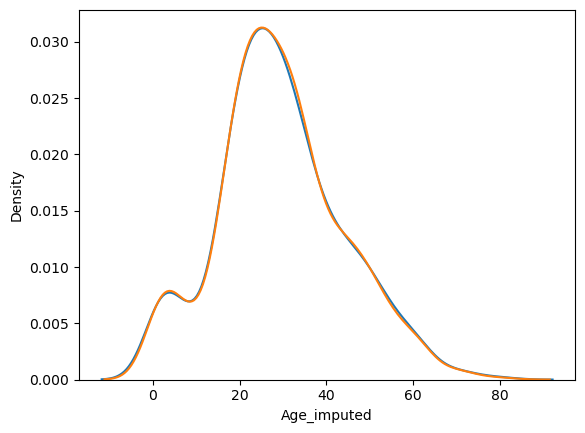

In [17]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label='Imputed',hist=False)

In [18]:
X_train['Age'].var()

210.2517072477438

In [19]:
X_train['Age_imputed'].var()

206.11675730021045

In [20]:
X_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2700.831981,71.580633,58.396317
Age,71.580633,210.251707,210.251707
Age_imputed,58.396317,210.251707,206.116757


<Axes: >

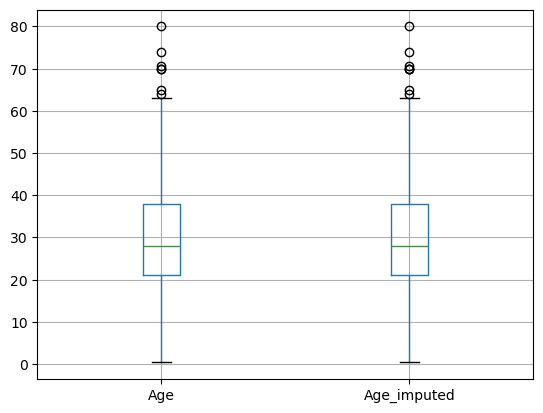

In [21]:
X_train[['Age','Age_imputed']].boxplot()

In [22]:
sampled_value = X_train['Age'].dropna().sample(1,random_state=int(observation['Fare']))

NameError: name 'observation' is not defined

Categorical Data

In [44]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [45]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [46]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [47]:
X = data
y = data.iloc[:,-1]

In [48]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [49]:
X_train['GarageQual_imputed']=X_train['GarageQual']
X_test['GarageQual_imputed']=X_test['GarageQual']

X_train['FireplaceQu_imputed']=X_train['FireplaceQu']
X_test['FireplaceQu_imputed']=X_test['FireplaceQu']

In [50]:
X_test

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
892,NaN,TA,154500,TA,NaN
1105,TA,TA,325000,TA,TA
413,Gd,TA,115000,TA,Gd
522,Gd,TA,159000,TA,Gd
1036,Ex,TA,315500,TA,Ex
...,...,...,...,...,...
479,NaN,TA,89471,TA,NaN
1361,Gd,TA,260000,TA,Gd
802,Gd,TA,189000,TA,Gd
651,Gd,Fa,108000,Fa,Gd


In [51]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FirePlaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values


C:\Users\yango\AppData\Local\Temp\ipykernel_26324\915698534.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual

KeyError: 'FirePlaceQu'

In [52]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1374,Gd,TA,250000,TA,Gd
146,NaN,Fa,105000,Fa,Gd
1150,Gd,TA,124000,TA,Gd
520,NaN,NaN,106250,TA,Gd
790,Gd,TA,160200,TA,Gd


In [56]:
temp = pd.concat( [
                    X_train['GarageQual'].value_counts()/len(X_train['GarageQual'].dropna()),
                    X_train['GarageQual_imputed'].value_counts()/len(X_train) ], axis=1 )
temp.columns = ['original','imputed']
temp

,original,imputed
TA,0.951087,0.950342
Fa,0.032609,0.034247
Gd,0.011775,0.011130
Ex,0.002717,0.002568
Po,0.001812,0.001712


In [61]:
len(X_train)

1168

In [62]:
X_train.shape

(1168, 5)

In [63]:
temp = pd.concat( [
                    X_train['FireplaceQu'].value_counts()/len(X_train['FireplaceQu'].dropna()),
                    X_train['FireplaceQu_imputed'].value_counts()/len(X_train) ], axis=1 )
temp.columns = ['original','imputed']
temp

,original,imputed
Gd,0.491143,0.489726
TA,0.405797,0.408390
Fa,0.043478,0.041952
Ex,0.033816,0.034247
Po,0.025765,0.025685
